In [1]:

import numpy as np
from tqdm import trange
from pathlib import Path
import matplotlib.pyplot as plt
import time
import sys
import pandas as pd
import scipy
import sympy as sp
from scipy.interpolate import interp1d


import sklearn.gaussian_process as gp
from scipy import stats


sys.path.append('../..')
sys.path.append('..')
import plot_settings
import importlib
#import multi_exp_log
import Param_symbol

import GP



from IPython.display import display, Math

colors = plot_settings.colors()

def import_reload():
    plot_settings.apply()
    importlib.reload(plot_settings)
    importlib.reload(Param_symbol)
    importlib.reload(GP)

import_reload()
GP_FIT = GP.GP_process()

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/5_Multi/sr/../GP.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


# Importing data

In [2]:
RUN_ID = 'all1'
DT = 1
Q0 = 17921.57581 

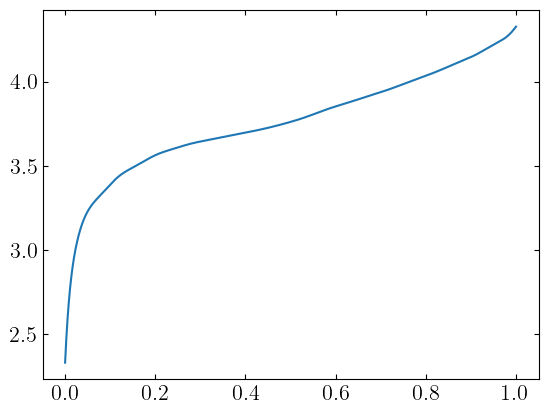

In [3]:
soc = np.linspace(0,1,int(2.5e4))
Ue = GP.soc_to_Ue(soc,GP_FIT) 
plt.plot(soc, Ue)

In [4]:
X_train = soc.reshape(-1,1)
Y_train = Ue.reshape(-1,1)

In [5]:
def print_models(df_model):
    for i in range(len(df_model)):
        print(f"Model {i}: Complexity={df_model['complexity'][i]}, Loss={df_model['loss'][i]}")
        print(f"Equation: {df_model['equation'][i]}\n")

def print_best_model(model, model_index = None):
    best = model.get_best()
    display(Math(f'\\LARGE {model.latex(model_index)}'))
    display(Math(r'\LARGE $x_0 = \mathrm{{c}}$-rate$'))
    display(Math(r'\LARGE $x_1 = \Delta u / L_{{tot}}$'))
    display(Math(r'\LARGE $x_2 = \mathrm{SOC}$'))
    print(f'Best model in symbolic form: {model.sympy()}\nLoss: {best["loss"]}\nBest model complexity: {best["complexity"]}')

In [6]:
# Parity plot
def pareto_plot(model):
    df_model = model.equations_
    best = model.get_best()
    plt.grid(True, which="both", ls="-", linewidth=0.5)
    plt.plot(df_model['complexity'], df_model['loss'], marker='o', linestyle='-', color=colors[0], label='Models')
    plt.plot(best['complexity'], best['loss'],'o', color=colors[1], label='Best Model')
    plt.xlabel('Complexity')
    plt.ylabel('Loss')
    plt.yscale('log')
    plt.title('Model Complexity vs Loss')
    plt.legend()
    plt.show()

def parity_plot(model, X_test = X_train, Y_test = Y_train):


    Y_pred = model.predict(X_test)
    plt.scatter(Y_test, Y_pred, color=colors[0],alpha = 0.5)
    plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'k--', lw=2)
    plt.xlabel(f'Actual $U_e$ [a.u.]')
    plt.ylabel(f'Predicted $U_e$ [a.u.]')
    plt.show()

def save_expressions(df_model, element):
    df_model.to_csv(f'model_{element}.csv', index=False)

# $U_{eq} = f_U(\mathrm{SOC})$

In [7]:
import_reload()
model_Ue = Param_symbol.run_symbolic_regression(X_train, Y_train, model = None,run_id = f'Ue_{RUN_ID}')

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


In [8]:
df_model_Ue = model_Ue.equations_

In [9]:
print_models(df_model_Ue)

Model 0: Complexity=1, Loss=0.09608596
Equation: 3.7619514

Model 1: Complexity=3, Loss=0.010141228
Equation: x0 + 3.261987

Model 2: Complexity=4, Loss=0.009408141
Equation: sqrt(x0) + 3.0953002

Model 3: Complexity=5, Loss=0.0054167793
Equation: sqrt(tan(x0)) + 3.0347118

Model 4: Complexity=6, Loss=0.002812314
Equation: (tan(x0) ^ 0.079775505) * 4.01719

Model 5: Complexity=7, Loss=0.0014232817
Equation: (tan(sinh(x0)) ^ 0.07387887) * 3.9690666

Model 6: Complexity=8, Loss=0.00091660296
Equation: (tan(x0 * 1.4016778) ^ 0.06744576) * 3.8342545

Model 7: Complexity=9, Loss=0.0009071011
Equation: (tan(sinh(x0) * 1.1627426) ^ 0.067934014) * 3.8871794

Model 8: Complexity=10, Loss=0.0006801537
Equation: ((x0 ^ 0.10180602) * 2.9832892) + cosh(tanh(cube(x0)))

Model 9: Complexity=11, Loss=0.00022323059
Equation: cosh(sinh(sin(x0) ^ 0.21716943) + cosh(0.7887963 - x0))

Model 10: Complexity=12, Loss=0.00013337737
Equation: ((x0 ^ 0.24302228) * 3.192523) + cosh(sinh(x0 - cos(x0)))

Model 11: 

In [10]:
print_best_model(model_Ue)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: sinh((x0 + 0.0003660555)**0.1737191*1.1470618 + cosh(sinh(tanh(x0)) - 1*0.672644))
Loss: 9.52995e-05
Best model complexity: 15


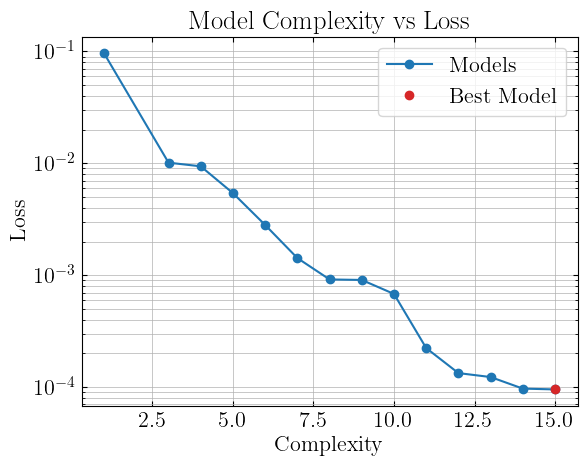

In [11]:
pareto_plot(model_Ue)

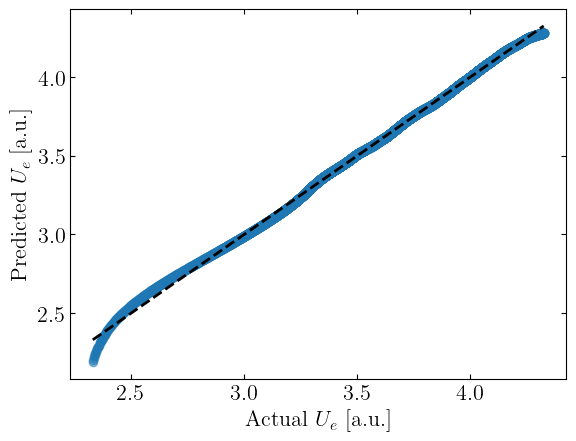

In [12]:
parity_plot(model_Ue)

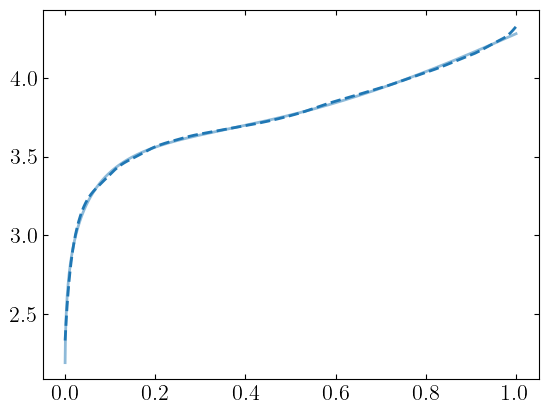

In [13]:
plt.plot(soc, model_Ue.predict(X_train), color=colors[0], alpha = 0.5, label = 'SR fit', lw = 2)
plt.plot(soc, Ue, color = colors[0],ls = '--', lw = 2, label = 'GP fit')

In [14]:
SAVE  = True
if SAVE:
    save_expressions(df_model_Ue,  f'Ue_accuracy')
    #save_expressions(df_model_R1, f'R1_{RUN_ID}')
    #save_expressions(df_model_C1, f'C1_{RUN_ID}')